In [288]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as stats

In [289]:
#input params indices - is used to calculate spread
index1= "^MOVE"
index2= "^VIX"

#Tradable securities - proxies used to trade the spread
ticker1 = "TLT"
ticker2 = "SPY"

hp_short = 0 #holding period (number of days) for the short position
hp_long = 3  #holding period (number of days) for the long position

#input params for the strategy
zscore_threshold = 2.0 #standard is 2

#input params for the backtest
window = 60 #assumes SMA
start_date = '2020-01-01'
end_date = '2025-04-15' #not in use atm

In [290]:
# Download data for given index1
i1 = yf.download(index1, start=start_date)["Close"]
i1.name = f"{index1}"

[*********************100%***********************]  1 of 1 completed


In [291]:
# Download VXZ as a proxy for MOVE (not perfect, just illustrative)
# VXZ is a medium-term VIX futures ETF, loosely tied to vol of rates via macro shocks
i2 = yf.download(index2, start=start_date)["Close"]
i2.name = f"{index2}"

[*********************100%***********************]  1 of 1 completed


In [292]:
# Combine and clean
data = pd.concat([i1, i2], axis=1).dropna()

In [293]:
# Calculate divergence metrics
data["Spread"] = data[f"{index1}"] - data[f"{index2}"]
data["Ratio"] = data[f"{index1}"] / data[f"{index2}"]
data["Z_Score"] = (data["Spread"] - data["Spread"].rolling(window).mean()) / data["Spread"].rolling(window).std() #assumes rolling SMA


In [294]:
# Optional: Flag extreme events
data["Stress_Signal"] = data["Z_Score"].apply(lambda z: "High" if z > zscore_threshold else ("Low" if z < -zscore_threshold else "Neutral"))


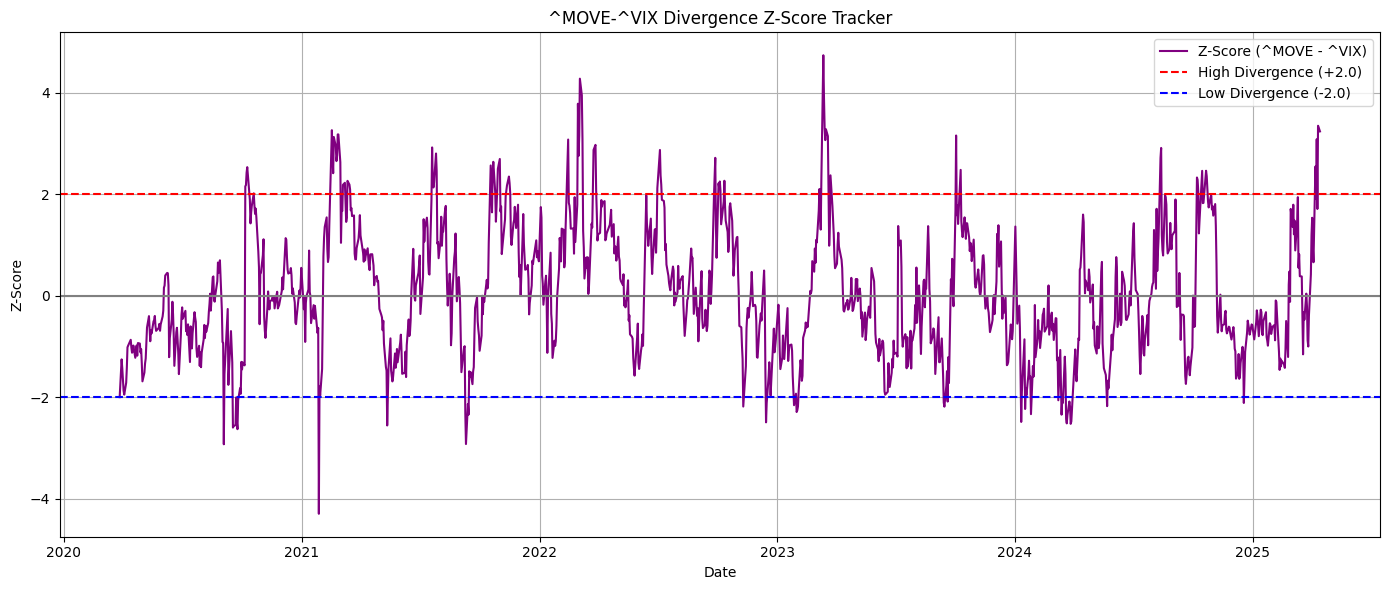

In [295]:
# Plot
plt.figure(figsize=(14, 6))
plt.plot(data.index, data["Z_Score"], label=f"Z-Score ({index1} - {index2})", color="purple")
plt.axhline(2, color="red", linestyle="--", label=f"High Divergence (+{zscore_threshold})")
plt.axhline(-2, color="blue", linestyle="--", label=f"Low Divergence (-{zscore_threshold})")
plt.axhline(0, color="gray", linestyle="-")
plt.title(f"{index1}-{index2} Divergence Z-Score Tracker")
plt.xlabel("Date")
plt.ylabel("Z-Score")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


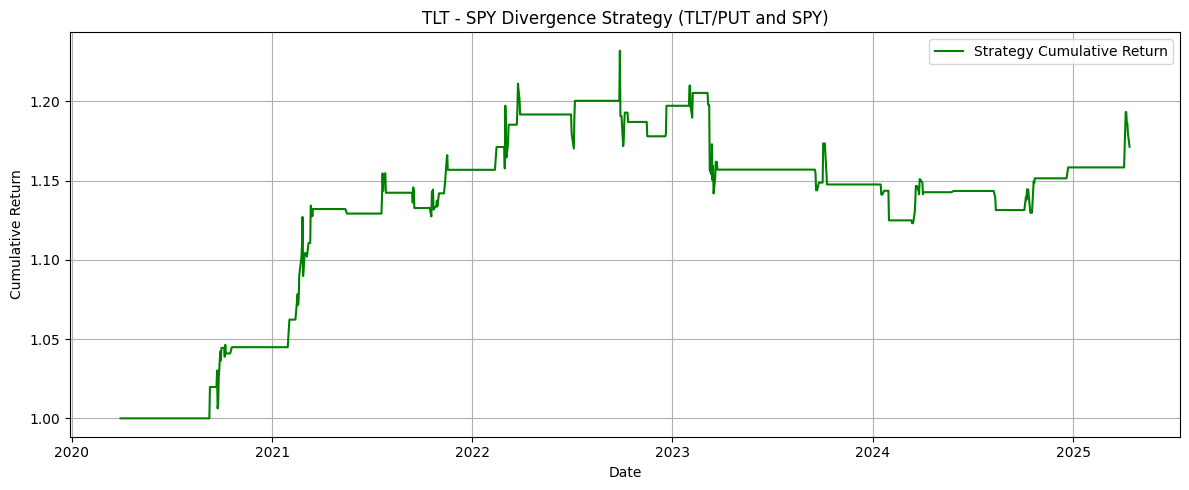

In [296]:
# Download index1 and index2 as proxies (should be Nordnet compatible)
t1 = yf.download(f"{ticker1}", start=data.index.min())["Close"]
t2 = yf.download(f"{ticker2}", start=data.index.min())["Close"]

# Combine with existing Z-score data
combined = pd.concat([data["Z_Score"], t1, t2], axis=1).dropna()
combined.columns = ["Z_Score", f"{ticker1}", f"{ticker2}"]

# Create trading signal:
# - If Z > threshold, simulate ticker1 short
# - If Z < -threshold, simulate ticker2 long 
combined["Signal"] = "Neutral"
combined.loc[combined["Z_Score"] > zscore_threshold, "Signal"] = f"Short_{ticker1}"
combined.loc[combined["Z_Score"] < -zscore_threshold, "Signal"] = f"Long_{ticker2}"

# Create position column (holding 1 day after signal trigger)
combined[f"Position_{ticker1}"] = combined["Signal"].shift(hp_short).apply(lambda x: -1 if x == f"Short_{ticker1}" else 0)
combined[f"Position_{ticker2}"] = combined["Signal"].shift(hp_long).apply(lambda x: 1 if x == f"Long_{ticker2}" else 0)

# Calculate daily returns
combined[f"Return_{ticker1}"] = combined[f"{ticker1}"].pct_change()
combined[f"Return_{ticker2}"] = combined[f"{ticker2}"].pct_change()

# Simulate strategy PnL
combined[f"PnL_{ticker1}"] = combined[f"Position_{ticker1}"] * combined[f"Return_{ticker1}"]
combined[f"PnL_{ticker2}"] = combined[f"Position_{ticker2}"] * combined[f"Return_{ticker2}"]
combined["PnL_Total"] = combined[f"PnL_{ticker1}"] + combined[f"PnL_{ticker2}"]
combined["Cumulative_Return"] = (1 + combined["PnL_Total"]).cumprod()

# Plot results
plt.figure(figsize=(12, 5))
plt.plot(combined["Cumulative_Return"], label="Strategy Cumulative Return", color="green")
plt.title(f"{ticker1} - {ticker2} Divergence Strategy ({ticker1}/PUT and {ticker2})")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [297]:
cagr = (combined["Cumulative_Return"].iloc[-1] ** (252 / len(combined)) - 1) * 100
volatility = combined["PnL_Total"].std() * np.sqrt(252) * 100
sharpe_ratio = (cagr - 0) / volatility
max_drawdown = (combined["Cumulative_Return"].cummax() - combined["Cumulative_Return"]).max() * 100
sortino_ratio = (cagr - 0) / combined["PnL_Total"][combined["PnL_Total"] < 0].std() * np.sqrt(252) * 100
calmar_ratio = cagr / abs(max_drawdown)
print(f"CAGR: {cagr:.2f}%")
print(f"Volatility: {volatility:.2f}%")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
print(f"Max Drawdown: {max_drawdown:.2f}%")
print(f"Sortino Ratio: {sortino_ratio:.2f}")
print(f"Calmar Ratio: {calmar_ratio:.2f}")

CAGR: 3.21%
Volatility: 5.94%
Sharpe Ratio: 0.54
Max Drawdown: 10.88%
Sortino Ratio: 644675.36
Calmar Ratio: 0.30


In [301]:
# Create a comparison table
spy = yf.download("SPY", start=data.index.min())["Close"]
spy_returns = spy.pct_change().dropna()
spy_cumulative = (1 + spy_returns).cumprod()
spy_volatility = spy_returns.std() * np.sqrt(252) * 100

comparison_table = pd.DataFrame({
    "Strategy": ["Your Portfolio", "Buy & Hold SPY"],
    "Risk (Std Dev)": [volatility, spy_volatility],
    "Sharpe Ratio": [sharpe_ratio, spy_returns.mean() / spy_returns.std()],
})

comparison_table

[*********************100%***********************]  1 of 1 completed


,Strategy,Risk (Std Dev),Sharpe Ratio
0,Your Portfolio,5.943147,0.540568
1,Buy & Hold SPY,Ticker SPY 21.606661 dtype: float64,Ticker SPY 0.039228 dtype: float64
